In [1]:
import math
import random
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda


## Load the CNN/DailyMail CSV files from the attached Kaggle dataset

We search for train.csv under /kaggle/input/ automatically (so it works regardless of the exact folder name), then load train/validation splits. We also take a smaller subset for speed, since training a from-scratch Transformer on the full ~300k articles would take too long.

In [2]:
candidates = glob.glob("/kaggle/input/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/cnn_dailymail/train.csv", recursive=True)
assert len(candidates) > 0, "Dataset not found — make sure you added it via Add Input."
train_path = candidates[0]
base_dir = train_path.rsplit("/", 1)[0]

train_df_full = pd.read_csv(f"{base_dir}/train.csv")
val_df_full = pd.read_csv(f"{base_dir}/validation.csv")

print(train_df_full.columns.tolist())
print(train_df_full.shape, val_df_full.shape)

N_TRAIN = 20000
N_VAL = 800

train_data = train_df_full.sample(n=N_TRAIN, random_state=SEED).reset_index(drop=True)
val_data = val_df_full.sample(n=N_VAL, random_state=SEED).reset_index(drop=True)

print(train_data.iloc[0]["article"][:300])
print("---SUMMARY---")
print(train_data.iloc[0]["highlights"])

['id', 'article', 'highlights']
(287113, 3) (13368, 3)
By . Mia De Graaf . Britons flocked to beaches across the southern coast yesterday as millions look set to bask in glorious sunshine today. Temperatures soared to 17C in Brighton and Dorset, with people starting their long weekend in deck chairs by the sea. Figures from Asda suggest the unexpected s
---SUMMARY---
People enjoyed temperatures of 17C at Brighton beach in West Sussex and Weymouth in Dorset .
Asda claims it will sell a million sausages over long weekend despite night temperatures dropping to minus 1C .
But the good weather has not been enjoyed by all as the north west and Scotland have seen heavy rain .


## Tokenization

We use a pretrained BERT tokenizer just for subword tokenization (WordPiece) — this is a preprocessing tool, not part of the model itself. The Transformer model (embeddings, attention, encoder, decoder) will be built entirely from scratch in the next steps.

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
VOCAB_SIZE = tokenizer.vocab_size

PAD_ID = tokenizer.pad_token_id
CLS_ID = tokenizer.cls_token_id   # used as <sos>
SEP_ID = tokenizer.sep_token_id   # used as <eos>

MAX_SRC_LEN = 256   # article length after truncation
MAX_TGT_LEN = 64    # summary length after truncation

print("Vocab size:", VOCAB_SIZE)
print("PAD:", PAD_ID, "CLS/<sos>:", CLS_ID, "SEP/<eos>:", SEP_ID)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 30522
PAD: 0 CLS/<sos>: 101 SEP/<eos>: 102


## PyTorch Dataset and DataLoader

We wrap the pandas DataFrame in a Dataset class that tokenizes each article/summary pair on the fly and pads to a fixed length, then build DataLoaders for training and validation.

In [4]:
class SummarizationDataset(Dataset):
    def __init__(self, df, tokenizer, max_src_len, max_tgt_len):
        self.data = df.reset_index(drop=True)
        self.tok = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        article = self.data.iloc[idx]["article"]
        summary = self.data.iloc[idx]["highlights"]

        src = self.tok(
            article, truncation=True, max_length=self.max_src_len,
            padding="max_length", return_tensors="pt"
        )
        tgt = self.tok(
            summary, truncation=True, max_length=self.max_tgt_len,
            padding="max_length", return_tensors="pt"
        )

        return {
            "src_ids": src["input_ids"].squeeze(0),
            "src_mask": src["attention_mask"].squeeze(0),
            "tgt_ids": tgt["input_ids"].squeeze(0),
            "tgt_mask": tgt["attention_mask"].squeeze(0),
        }


train_ds = SummarizationDataset(train_data, tokenizer, MAX_SRC_LEN, MAX_TGT_LEN)
val_ds = SummarizationDataset(val_data, tokenizer, MAX_SRC_LEN, MAX_TGT_LEN)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print({k: v.shape for k, v in batch.items()})

{'src_ids': torch.Size([16, 256]), 'src_mask': torch.Size([16, 256]), 'tgt_ids': torch.Size([16, 64]), 'tgt_mask': torch.Size([16, 64])}


## Positional Encoding

Self-attention has no built-in notion of word order, so we inject position information using sinusoidal positional encodings (as in the original "Attention is All You Need" paper).

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

## Multi-Head Attention

The core building block. We project queries, keys, and values, split them into multiple heads, compute scaled dot-product attention, and merge the heads back together.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        b, seq_len, _ = x.shape
        x = x.view(b, seq_len, self.n_heads, self.d_k)
        return x.permute(0, 2, 1, 3)

    def forward(self, query, key, value, mask=None):
        b = query.size(0)

        Q = self.split_heads(self.w_q(query))
        K = self.split_heads(self.w_k(key))
        V = self.split_heads(self.w_v(value))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-1e9"))

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, V)

        out = out.permute(0, 2, 1, 3).contiguous().view(b, -1, self.d_model)
        return self.w_o(out)

## Feed-Forward, Encoder Layer, Decoder Layer

The encoder layer applies self-attention then a feed-forward network, each with a residual connection and layer norm. The decoder layer adds a second attention block — cross-attention — which lets the decoder look at the encoder's output

In [7]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        attn_out = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, src_mask):
        attn_out = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_out))

        cross_out = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout(cross_out))

        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x

## The full Encoder-Decoder Transformer model

We combine the pieces above, add source/target masking (padding mask + look-ahead mask so the decoder can't see future tokens), and add a final linear layer that projects to vocabulary logits.

In [8]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=8, d_ff=1024,
                 n_layers=4, dropout=0.1, pad_id=0, max_len=512):
        super().__init__()
        self.d_model = d_model
        self.pad_id = pad_id

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

        self.output_proj = nn.Linear(d_model, vocab_size)

    def make_src_mask(self, src):
        return (src != self.pad_id).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        b, tgt_len = tgt.shape
        pad_mask = (tgt != self.pad_id).unsqueeze(1).unsqueeze(2)
        look_ahead = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt.device)).bool()
        return pad_mask & look_ahead

    def encode(self, src, src_mask):
        x = self.embedding(src) * math.sqrt(self.d_model)
        x = self.dropout(self.pos_encoding(x))
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, enc_out, tgt_mask, src_mask):
        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = self.dropout(self.pos_encoding(x))
        for layer in self.decoder_layers:
            x = layer(x, enc_out, tgt_mask, src_mask)
        return x

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        enc_out = self.encode(src, src_mask)
        dec_out = self.decode(tgt, enc_out, tgt_mask, src_mask)
        return self.output_proj(dec_out)

## Instantiate the model, optimizer, and loss function

In [9]:
model = Seq2SeqTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=256,
    n_heads=8,
    d_ff=1024,
    n_layers=4,
    dropout=0.1,
    pad_id=PAD_ID,
    max_len=max(MAX_SRC_LEN, MAX_TGT_LEN) + 10,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {n_params:,}")

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)

Trainable params: 23,030,586


## Training loop function (teacher forcing)

We feed the decoder the ground-truth summary shifted right by one position, and train it to predict the next token at each step.

In [10]:
def run_epoch(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0

    with torch.set_grad_enabled(train):
        for batch in loader:
            src = batch["src_ids"].to(device)
            tgt = batch["tgt_ids"].to(device)

            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            logits = model(src, tgt_in)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_out.reshape(-1)
            )

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)

## Run the training

In [11]:
N_EPOCHS = 12  # increase if time allows

history = {"train_loss": [], "val_loss": []}

for epoch in range(1, N_EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, optimizer, criterion, train=True)
    val_loss = run_epoch(model, val_loader, optimizer, criterion, train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch}/{N_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

torch.save(model.state_dict(), "scratch_transformer.pt")

Epoch 1/12 | train_loss=7.3346 | val_loss=6.8914
Epoch 2/12 | train_loss=6.7754 | val_loss=6.6053
Epoch 3/12 | train_loss=6.5153 | val_loss=6.4819
Epoch 4/12 | train_loss=6.3344 | val_loss=6.3740
Epoch 5/12 | train_loss=6.1928 | val_loss=6.3602
Epoch 6/12 | train_loss=6.0739 | val_loss=6.2522
Epoch 7/12 | train_loss=5.9721 | val_loss=6.1955
Epoch 8/12 | train_loss=5.8814 | val_loss=6.1587
Epoch 9/12 | train_loss=5.8025 | val_loss=6.1169
Epoch 10/12 | train_loss=5.7321 | val_loss=6.0797
Epoch 11/12 | train_loss=5.6676 | val_loss=6.0673
Epoch 12/12 | train_loss=5.6080 | val_loss=6.0616


## Training vs Validation Loss Curve

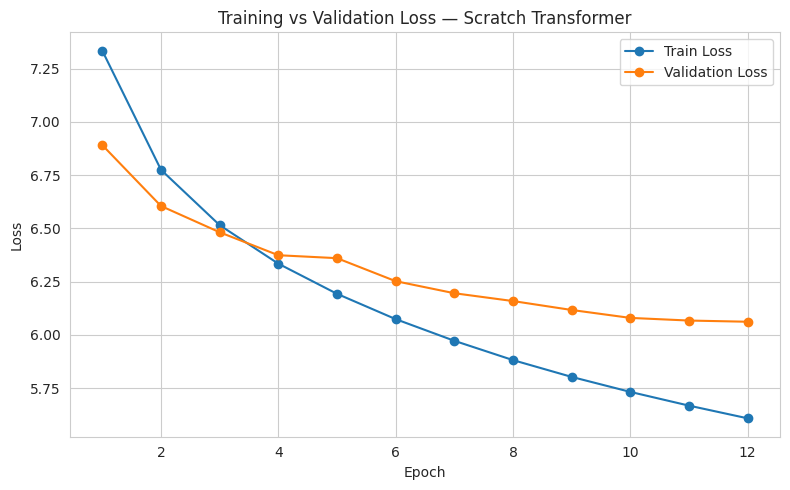

In [12]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss — Scratch Transformer")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

## Greedy decoding for generating summaries

### We start from <sos>, predict one token at a time, feed it back into the decoder, and stop at <eos> or max length.

In [13]:
@torch.no_grad()
def greedy_summarize(model, article_text, tokenizer, max_src_len=256, max_tgt_len=64):
    model.eval()

    src = tokenizer(
        article_text, truncation=True, max_length=max_src_len,
        padding="max_length", return_tensors="pt"
    )["input_ids"].to(device)

    src_mask = model.make_src_mask(src)
    enc_out = model.encode(src, src_mask)

    tgt_ids = torch.tensor([[CLS_ID]], device=device)

    for _ in range(max_tgt_len):
        tgt_mask = model.make_tgt_mask(tgt_ids)
        dec_out = model.decode(tgt_ids, enc_out, tgt_mask, src_mask)
        logits = model.output_proj(dec_out[:, -1, :])
        next_id = logits.argmax(dim=-1, keepdim=True)

        tgt_ids = torch.cat([tgt_ids, next_id], dim=1)
        if next_id.item() == SEP_ID:
            break

    return tokenizer.decode(tgt_ids[0], skip_special_tokens=True)


sample_article = val_data.iloc[0]["article"]
sample_reference = val_data.iloc[0]["highlights"]
generated = greedy_summarize(model, sample_article, tokenizer)

print("REFERENCE:\n", sample_reference)
print("\nGENERATED:\n", generated)

REFERENCE:
 Was last spotted in Burma in 1941,and was thought to have died out .
Scientists used a recording of its distinctive call to rediscover species .
Discovery proves bird and habitat both still exist in Myanmar .

GENERATED:
 the scientists found the bodies of the sun in the north of the sun in the north carolina. the discovery found the bodies of the bodies of the sun in the north of the world. the university of the university of the north carolina was found in the south of the south of the world ' s most famous. the scientists


## Evaluate with ROUGE

We score generated summaries against reference summaries on a sample of the validation set. Expect modest scores here — this is the from-scratch baseline, to be compared against fine-tuned BART later.

In [14]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

N_EVAL = 100
scores = {"rouge1": [], "rouge2": [], "rougeL": []}

for i in range(N_EVAL):
    article = val_data.iloc[i]["article"]
    reference = val_data.iloc[i]["highlights"]
    generated = greedy_summarize(model, article, tokenizer)

    result = scorer.score(reference, generated)
    for key in scores:
        scores[key].append(result[key].fmeasure)

for key, vals in scores.items():
    print(f"{key}: {np.mean(vals):.4f}")

rouge1: 0.1796
rouge2: 0.0268
rougeL: 0.1359


## ROUGE Scores Bar Chart

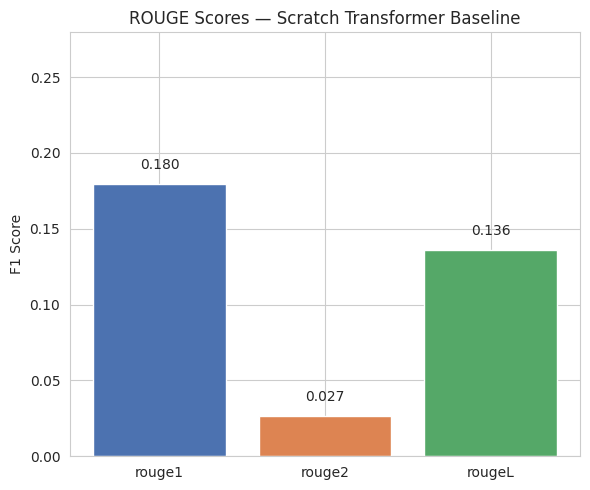

In [15]:
rouge_means = {k: np.mean(v) for k, v in scores.items()}

plt.figure(figsize=(6, 5))
bars = plt.bar(rouge_means.keys(), rouge_means.values(), color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylim(0, max(rouge_means.values()) + 0.1)
plt.ylabel("F1 Score")
plt.title("ROUGE Scores — Scratch Transformer Baseline")

for bar, val in zip(bars, rouge_means.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center")

plt.tight_layout()
plt.savefig("rouge_scores.png", dpi=150)
plt.show()

## Distribution of ROUGE-1 scores across samples

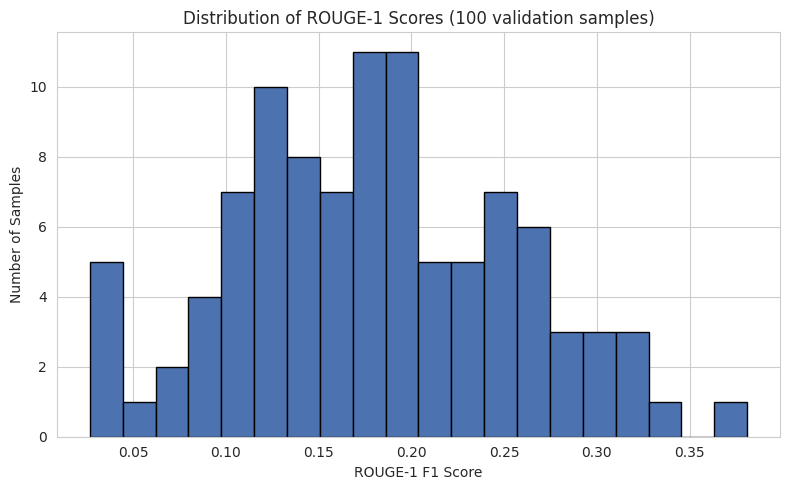

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(scores["rouge1"], bins=20, color="#4C72B0", edgecolor="black")
plt.xlabel("ROUGE-1 F1 Score")
plt.ylabel("Number of Samples")
plt.title("Distribution of ROUGE-1 Scores (100 validation samples)")
plt.tight_layout()
plt.savefig("rouge1_distribution.png", dpi=150)
plt.show()

## Attention Heatmap

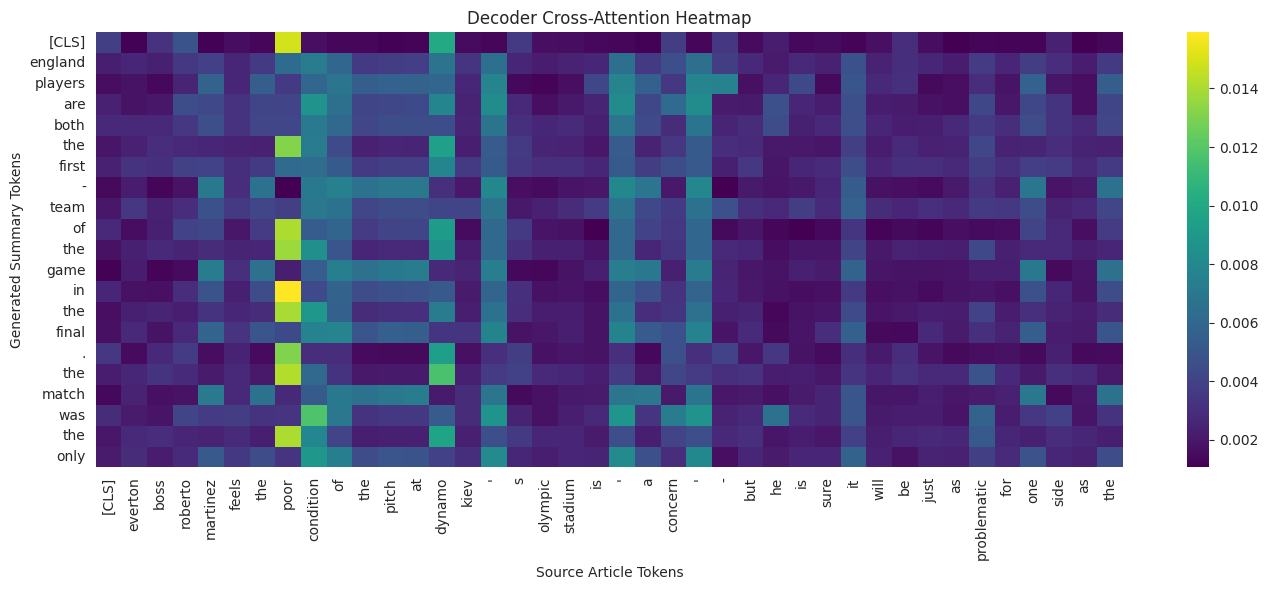

In [17]:
@torch.no_grad()
def get_cross_attention(model, article_text, tokenizer, max_src_len=256, max_gen_len=20):
    model.eval()
    src = tokenizer(
        article_text, truncation=True, max_length=max_src_len,
        padding="max_length", return_tensors="pt"
    )["input_ids"].to(device)

    src_mask = model.make_src_mask(src)
    enc_out = model.encode(src, src_mask)

    tgt_ids = torch.tensor([[CLS_ID]], device=device)
    attn_maps = []

   
    last_layer = model.decoder_layers[-1]

    for _ in range(max_gen_len):
        tgt_mask = model.make_tgt_mask(tgt_ids)
        dec_out = model.decode(tgt_ids, enc_out, tgt_mask, src_mask)
        logits = model.output_proj(dec_out[:, -1, :])
        next_id = logits.argmax(dim=-1, keepdim=True)
        tgt_ids = torch.cat([tgt_ids, next_id], dim=1)
        if next_id.item() == SEP_ID:
            break

    
    tgt_mask_full = model.make_tgt_mask(tgt_ids)
    x = model.embedding(tgt_ids) * math.sqrt(model.d_model)
    x = model.pos_encoding(x)
    for layer in model.decoder_layers[:-1]:
        x = layer(x, enc_out, tgt_mask_full, src_mask)

    # نعيد حساب الـ cross-attention بتاعة آخر layer يدوي عشان نطلع الـ weights
    Q = last_layer.cross_attn.split_heads(last_layer.cross_attn.w_q(x))
    K = last_layer.cross_attn.split_heads(last_layer.cross_attn.w_k(enc_out))
    scores_ca = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(last_layer.cross_attn.d_k)
    weights = F.softmax(scores_ca, dim=-1)  # (1, n_heads, tgt_len, src_len)

    avg_weights = weights.mean(dim=1)[0]  # average across heads -> (tgt_len, src_len)
    return tgt_ids[0], src[0], avg_weights.cpu().numpy()


sample_article = val_data.iloc[2]["article"]
tgt_ids, src_ids, attn_weights = get_cross_attention(model, sample_article, tokenizer)

tgt_tokens = tokenizer.convert_ids_to_tokens(tgt_ids)
src_tokens = tokenizer.convert_ids_to_tokens(src_ids)


N_SRC_SHOW = 40

plt.figure(figsize=(14, 6))
sns.heatmap(
    attn_weights[:, :N_SRC_SHOW],
    xticklabels=src_tokens[:N_SRC_SHOW],
    yticklabels=tgt_tokens,
    cmap="viridis",
)
plt.xlabel("Source Article Tokens")
plt.ylabel("Generated Summary Tokens")
plt.title("Decoder Cross-Attention Heatmap")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("attention_heatmap.png", dpi=150)
plt.show()

## Sample Predictions Table (Reference vs Generated)

In [18]:
sample_results = []
for i in range(5):
    article = val_data.iloc[i]["article"]
    reference = val_data.iloc[i]["highlights"]
    generated = greedy_summarize(model, article, tokenizer)
    r1 = scorer.score(reference, generated)["rouge1"].fmeasure
    sample_results.append({
        "Reference": reference[:100] + "...",
        "Generated": generated[:100] + "...",
        "ROUGE-1": round(r1, 3)
    })

results_df = pd.DataFrame(sample_results)
results_df

,Reference,Generated,ROUGE-1
0,"Was last spotted in Burma in 1941,and was thou...",the scientists found the bodies of the sun in ...,0.147
1,Pastor Mal Feebrey discovered he had terminal ...,"dr. lee, 19, was diagnosed with a disease in a...",0.153
2,Everton take on Dynamo Kiev in the Europa Leag...,england players are both the first - team of t...,0.186
3,Hospitals still failing to claw back the cost ...,nhs chief executive says the nhs will be ' s '...,0.161
4,North Carolina State University has disbanded ...,the state university of virginia student was a...,0.078
